# 📊 Customer Purchase Behavior Analysis
### Data Visualization with Python — 24CSE463
**New Horizon College of Engineering**

| Detail | Value |
|--------|-------|
| Student | Roshni Sakana |
| Subject | DVP — 24CSE463 |
| Tools | Python · Pandas · Matplotlib · Seaborn |
| Dataset | 5,000 transactions · 500 customers · 2023–2024 |

---

## ⚙️ Step 1 — Import Libraries
We import all required Python libraries before starting the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
PALETTE = sns.color_palette('Set2')

print('✅ All libraries imported successfully!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ All libraries imported successfully!
   pandas  2.3.3
   numpy   2.3.5
   seaborn 0.13.2


---
## 📁 Step 2 — Generate Dataset
We generate a realistic synthetic customer transaction dataset with 5,000 records.

In [2]:
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

NUM_CUSTOMERS = 500
NUM_TRANSACTIONS = 5000

categories = ['Electronics', 'Clothing', 'Groceries', 'Home & Kitchen', 'Sports', 'Books', 'Beauty']
products = {
    'Electronics':    ['Laptop', 'Headphones', 'Smartphone', 'Tablet', 'Smart Watch'],
    'Clothing':       ['T-Shirt', 'Jeans', 'Jacket', 'Sneakers', 'Dress'],
    'Groceries':      ['Organic Milk', 'Bread', 'Eggs', 'Rice', 'Pasta'],
    'Home & Kitchen': ['Blender', 'Coffee Maker', 'Cookware Set', 'Air Fryer', 'Vacuum'],
    'Sports':         ['Yoga Mat', 'Dumbbells', 'Running Shoes', 'Bicycle', 'Gym Bag'],
    'Books':          ['Fiction Novel', 'Self-Help', 'Cookbook', 'Textbook', 'Biography'],
    'Beauty':         ['Moisturizer', 'Lipstick', 'Perfume', 'Shampoo', 'Sunscreen'],
}
price_range = {
    'Electronics': (50, 1500), 'Clothing': (15, 200), 'Groceries': (2, 50),
    'Home & Kitchen': (30, 400), 'Sports': (20, 500), 'Books': (5, 80), 'Beauty': (8, 150),
}
cities  = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Pune', 'Kolkata', 'Ahmedabad']
genders = ['Male', 'Female', 'Other']
payment = ['Credit Card', 'Debit Card', 'UPI', 'Net Banking', 'Cash on Delivery']

customer_ids  = [f'CUST{str(i).zfill(4)}' for i in range(1, NUM_CUSTOMERS + 1)]
customer_city = {c: random.choice(cities)  for c in customer_ids}
customer_age  = {c: random.randint(18, 65) for c in customer_ids}
customer_gen  = {c: random.choice(genders) for c in customer_ids}

start_date = datetime(2023, 1, 1)
end_date   = datetime(2024, 12, 31)
date_range = (end_date - start_date).days

records = []
for i in range(1, NUM_TRANSACTIONS + 1):
    cust  = random.choice(customer_ids)
    cat   = random.choice(categories)
    prod  = random.choice(products[cat])
    lo, hi = price_range[cat]
    price = round(random.uniform(lo, hi), 2)
    qty   = random.randint(1, 5)
    total = round(price * qty, 2)
    disc  = round(random.uniform(0, 0.30), 2)
    final = round(total * (1 - disc), 2)
    date  = start_date + timedelta(days=random.randint(0, date_range))
    records.append({
        'transaction_id': f'TXN{str(i).zfill(5)}', 'customer_id': cust,
        'date': date.strftime('%Y-%m-%d'), 'category': cat, 'product': prod,
        'unit_price': price, 'quantity': qty, 'total_amount': total,
        'discount': disc, 'final_amount': final, 'payment_method': random.choice(payment),
        'city': customer_city[cust], 'age': customer_age[cust], 'gender': customer_gen[cust],
    })

df_raw = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
df_raw.to_csv('customer_transactions.csv', index=False)
print(f'✅ Dataset generated: {len(df_raw)} transactions, {df_raw["customer_id"].nunique()} customers')
print(f'   Date range  : {df_raw["date"].min()}  →  {df_raw["date"].max()}')
print(f'   Categories  : {df_raw["category"].nunique()}')
print(f'   Cities      : {df_raw["city"].nunique()}')

✅ Dataset generated: 5000 transactions, 500 customers
   Date range  : 2023-01-01  →  2024-12-31
   Categories  : 7
   Cities      : 8


---
## 🔍 Step 3 — Load & Inspect Data
Load the CSV and examine its structure, shape, and first few rows.

In [3]:
df = pd.read_csv('customer_transactions.csv', parse_dates=['date'])

print('='*55)
print(f'  Shape          : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'  Date Range     : {df["date"].min().date()}  →  {df["date"].max().date()}')
print(f'  Unique Customers: {df["customer_id"].nunique()}')
print(f'  Unique Products : {df["product"].nunique()}')
print('='*55)
df.head(8)

  Shape          : 5000 rows × 14 columns
  Date Range     : 2023-01-01  →  2024-12-31
  Unique Customers: 500
  Unique Products : 35


,transaction_id,customer_id,date,category,product,unit_price,quantity,total_amount,discount,final_amount,payment_method,city,age,gender
0,TXN02432,CUST0366,2023-01-01,Home & Kitchen,Blender,116.08,4,464.32,0.22,362.17,UPI,Mumbai,36,Female
1,TXN01714,CUST0213,2023-01-01,Beauty,Sunscreen,70.54,5,352.70,0.24,268.05,UPI,Kolkata,24,Other
2,TXN02673,CUST0165,2023-01-01,Home & Kitchen,Vacuum,213.76,2,427.52,0.02,418.97,Debit Card,Chennai,53,Male
3,TXN02522,CUST0002,2023-01-01,Beauty,Sunscreen,28.10,3,84.30,0.15,71.66,Cash on Delivery,Mumbai,34,Other
4,TXN04552,CUST0207,2023-01-02,Beauty,Sunscreen,26.97,1,26.97,0.23,20.77,Credit Card,Ahmedabad,53,Male
5,TXN00290,CUST0418,2023-01-02,Clothing,Sneakers,71.76,3,215.28,0.04,206.67,Cash on Delivery,Kolkata,59,Female
6,TXN03927,CUST0340,2023-01-02,Clothing,Jeans,112.22,2,224.44,0.22,175.06,Credit Card,Chennai,54,Other
7,TXN04755,CUST0114,2023-01-02,Home & Kitchen,Coffee Maker,50.48,3,151.44,0.03,146.90,Net Banking,Hyderabad,57,Other


In [4]:
# Summary statistics
df[['unit_price','quantity','total_amount','final_amount','discount']].describe().round(2)

,unit_price,quantity,total_amount,final_amount,discount
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,212.84,2.98,635.14,540.05,0.15
std,300.66,1.42,1028.29,879.92,0.09
min,2.03,1.00,2.23,1.58,0.00
25%,39.17,2.00,96.69,81.81,0.07
50%,93.91,3.00,242.28,205.26,0.15
75%,250.48,4.00,685.62,572.35,0.23
max,1499.73,5.00,7477.15,6911.33,0.30


---
## 🧹 Step 4 — Data Cleaning & Feature Engineering
Remove duplicates and nulls, then create useful derived columns.

In [5]:
before = len(df)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print(f'✅ Removed {before - len(df)} duplicate/null rows. Remaining: {len(df)}')

# Derived columns
df['month']       = df['date'].dt.to_period('M').astype(str)
df['month_name']  = df['date'].dt.strftime('%b %Y')
df['year']        = df['date'].dt.year
df['day_of_week'] = df['date'].dt.day_name()
df['age_group']   = pd.cut(df['age'], bins=[17,25,35,45,55,65],
                            labels=['18–25','26–35','36–45','46–55','56–65'])

print('✅ Derived columns added:')
print('   month | year | day_of_week | age_group')
print()
print('📋 Null check:')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else '   No null values found ✅')

✅ Removed 0 duplicate/null rows. Remaining: 5000
✅ Derived columns added:
   month | year | day_of_week | age_group

📋 Null check:
   No null values found ✅


---
## 🔗 Step 5 — Correlation Analysis
Check relationships between numerical variables using a heatmap.

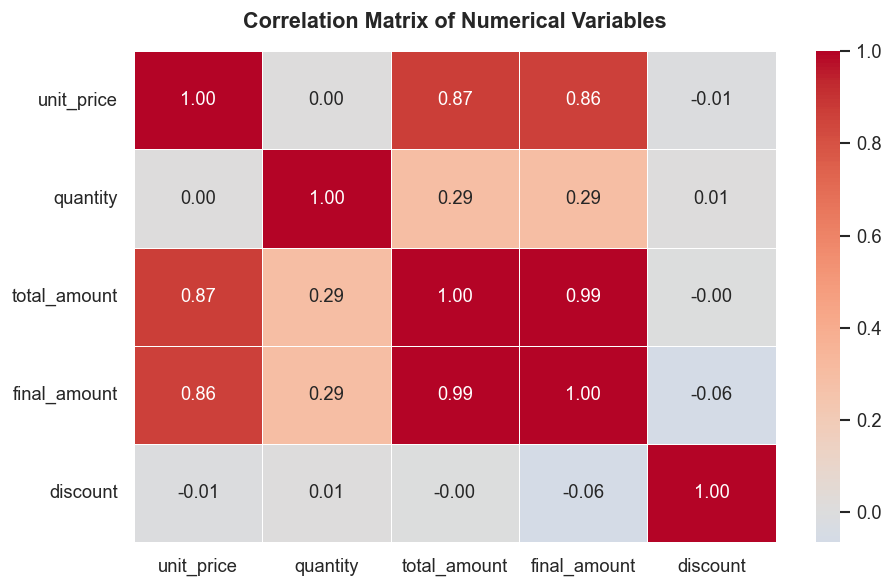

✅ Correlation heatmap saved: plot_correlation.png


In [6]:
numeric_cols = ['unit_price', 'quantity', 'total_amount', 'final_amount', 'discount']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Correlation Matrix of Numerical Variables', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('plot_correlation.png', bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap saved: plot_correlation.png')

---
## 📈 Step 6 — Sales Trends Over Time
Visualize monthly revenue and order count across 2023–2024.

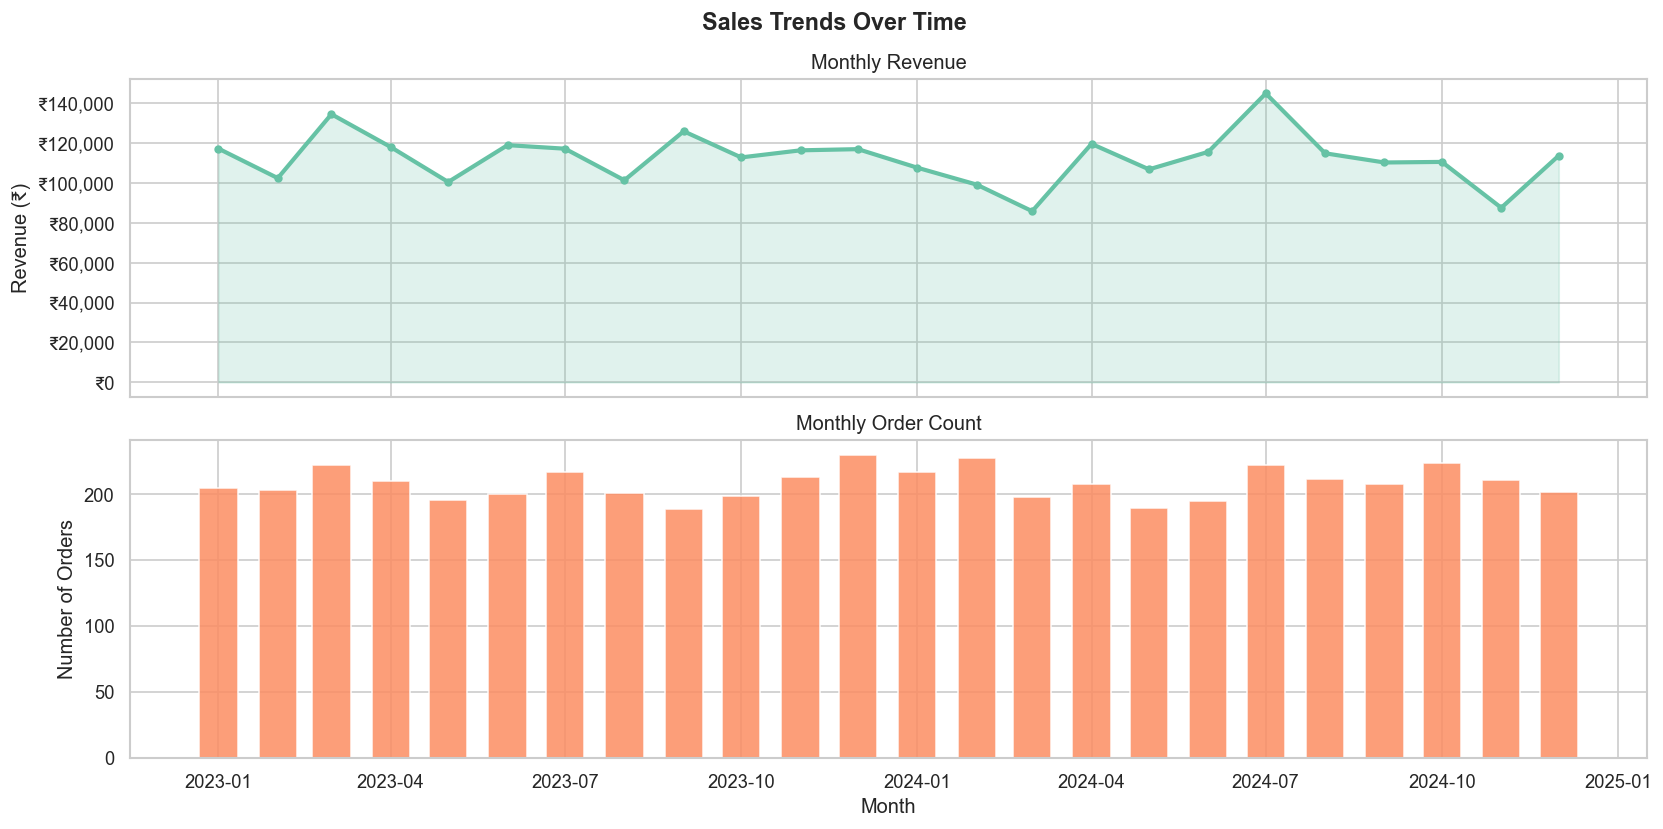

✅ Plot saved: plot1_sales_trends.png
   📌 Peak revenue: ₹144,983 in 2024-07
   📌 Avg monthly revenue: ₹112,511


In [7]:
monthly = (df.groupby('month')
             .agg(revenue=('final_amount','sum'), orders=('transaction_id','count'))
             .reset_index())
monthly['month_dt'] = pd.to_datetime(monthly['month'])
monthly.sort_values('month_dt', inplace=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Sales Trends Over Time', fontsize=14, fontweight='bold')

# Revenue
axes[0].fill_between(monthly['month_dt'], monthly['revenue'], alpha=0.2, color=PALETTE[0])
axes[0].plot(monthly['month_dt'], monthly['revenue'], color=PALETTE[0], lw=2.5, marker='o', ms=4)
axes[0].set_ylabel('Revenue (₹)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
axes[0].set_title('Monthly Revenue')

# Orders
axes[1].bar(monthly['month_dt'], monthly['orders'], color=PALETTE[1], alpha=0.85, width=20)
axes[1].set_ylabel('Number of Orders')
axes[1].set_xlabel('Month')
axes[1].set_title('Monthly Order Count')

plt.tight_layout()
plt.savefig('plot1_sales_trends.png', bbox_inches='tight')
plt.show()

peak = monthly.loc[monthly['revenue'].idxmax()]
print(f'✅ Plot saved: plot1_sales_trends.png')
print(f'   📌 Peak revenue: ₹{peak["revenue"]:,.0f} in {peak["month"]}')
print(f'   📌 Avg monthly revenue: ₹{monthly["revenue"].mean():,.0f}')

---
## 🏷️ Step 7 — Top Products & Categories
Identify which categories and products generate the most revenue.

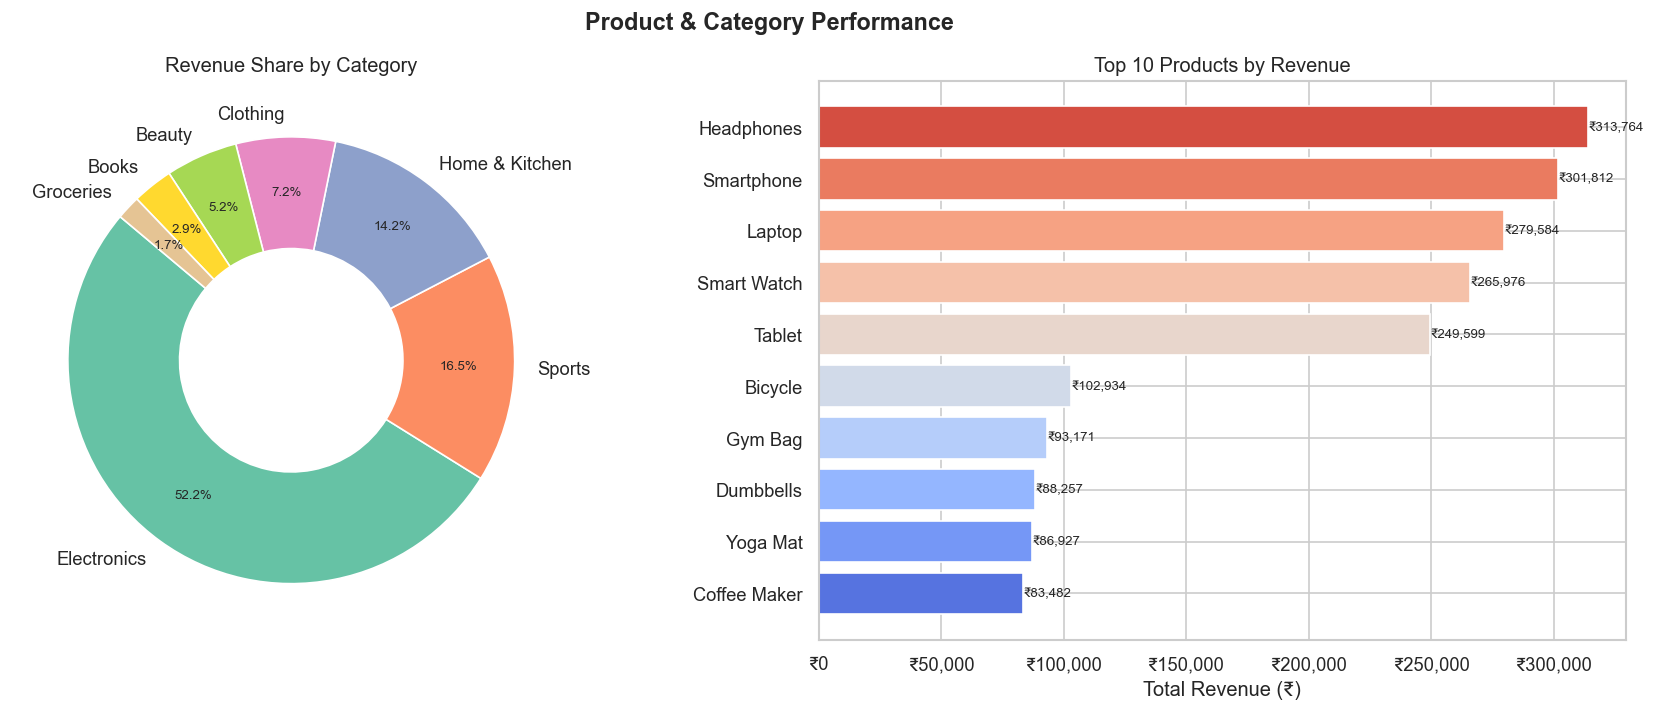

✅ Plot saved: plot2_top_products.png
   📌 Top category  : Electronics  (₹1,410,736)
   📌 Top product   : Headphones  (₹313,764)


In [8]:
cat_rev  = df.groupby('category')['final_amount'].sum().sort_values(ascending=False)
prod_rev = df.groupby('product')['final_amount'].sum().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Product & Category Performance', fontsize=14, fontweight='bold')

# Category donut
wedges, texts, autotexts = axes[0].pie(
    cat_rev, labels=cat_rev.index, autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('Set2', len(cat_rev)),
    wedgeprops=dict(width=0.5), pctdistance=0.75)
for at in autotexts: at.set_fontsize(8)
axes[0].set_title('Revenue Share by Category')

# Top 10 products
bars = axes[1].barh(prod_rev.index[::-1], prod_rev.values[::-1],
                    color=sns.color_palette('coolwarm', 10))
axes[1].set_xlabel('Total Revenue (₹)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
axes[1].set_title('Top 10 Products by Revenue')
for bar, val in zip(bars, prod_rev.values[::-1]):
    axes[1].text(val + 200, bar.get_y() + bar.get_height()/2,
                 f'₹{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot2_top_products.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: plot2_top_products.png')
print(f'   📌 Top category  : {cat_rev.index[0]}  (₹{cat_rev.iloc[0]:,.0f})')
print(f'   📌 Top product   : {prod_rev.index[0]}  (₹{prod_rev.iloc[0]:,.0f})')

---
## 👥 Step 8 — Customer Segmentation (RFM Analysis)
Segment customers into 5 groups based on Recency, Frequency, and Monetary value.

In [9]:
snapshot = df['date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency   = ('date',          lambda x: (snapshot - x.max()).days),
    Frequency = ('transaction_id','count'),
    Monetary  = ('final_amount',  'sum')
).reset_index()

rfm['R'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

def segment(score):
    if score >= 10:   return 'Champions'
    elif score >= 8:  return 'Loyal Customers'
    elif score >= 6:  return 'Potential Loyalists'
    elif score >= 4:  return 'At Risk'
    else:             return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

print('📊 RFM Segment Summary:')
print('='*55)
summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
summary['Count'] = rfm.groupby('Segment')['customer_id'].count()
print(summary.to_string())

📊 RFM Segment Summary:
                     Recency  Frequency  Monetary  Count
Segment                                                 
At Risk                132.3        7.3    3143.4     87
Champions               29.8       13.2    8586.8    116
Lost                   212.6        5.6    1539.0     32
Loyal Customers         57.7       10.9    6018.1    147
Potential Loyalists     76.8        8.9    4210.3    118


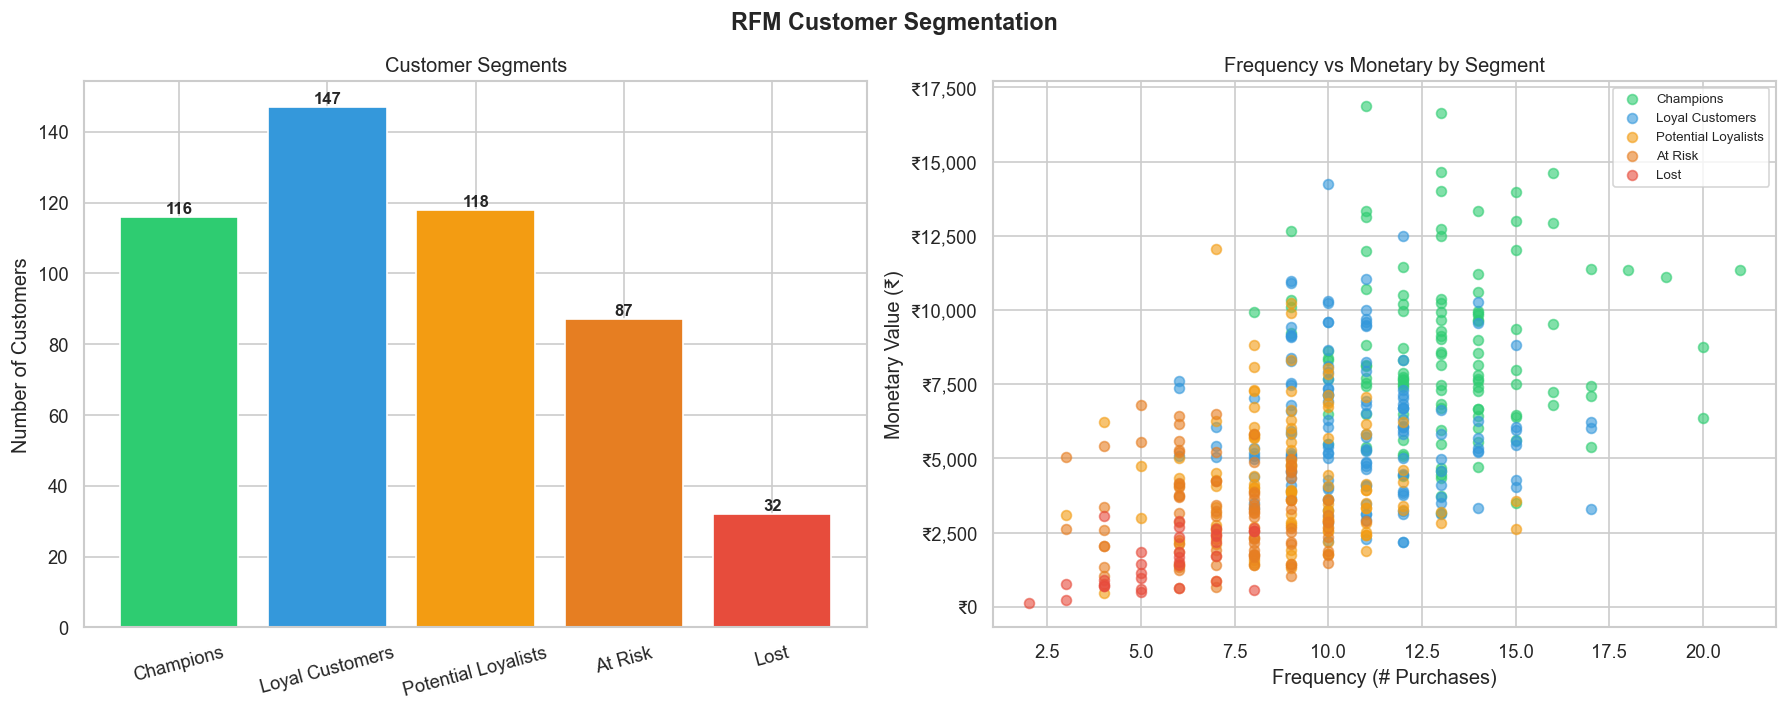

✅ Plot saved: plot3_rfm_segmentation.png


In [10]:
seg_order  = ['Champions','Loyal Customers','Potential Loyalists','At Risk','Lost']
seg_colors = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c']
seg_palette = dict(zip(seg_order, seg_colors))
seg_counts = rfm['Segment'].value_counts().reindex(seg_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold')

# Bar chart
axes[0].bar(seg_counts.index, seg_counts.values,
            color=[seg_colors[seg_order.index(s)] for s in seg_counts.index],
            edgecolor='white', linewidth=1)
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Segments')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Scatter
for seg in seg_order:
    sub = rfm[rfm['Segment'] == seg]
    axes[1].scatter(sub['Frequency'], sub['Monetary'],
                    label=seg, alpha=0.6, s=35, color=seg_palette[seg])
axes[1].set_xlabel('Frequency (# Purchases)')
axes[1].set_ylabel('Monetary Value (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
axes[1].set_title('Frequency vs Monetary by Segment')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot3_rfm_segmentation.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: plot3_rfm_segmentation.png')

---
## 💸 Step 9 — Spending Distribution
Analyze how spending varies across transaction amounts, categories, age groups, and payment methods.

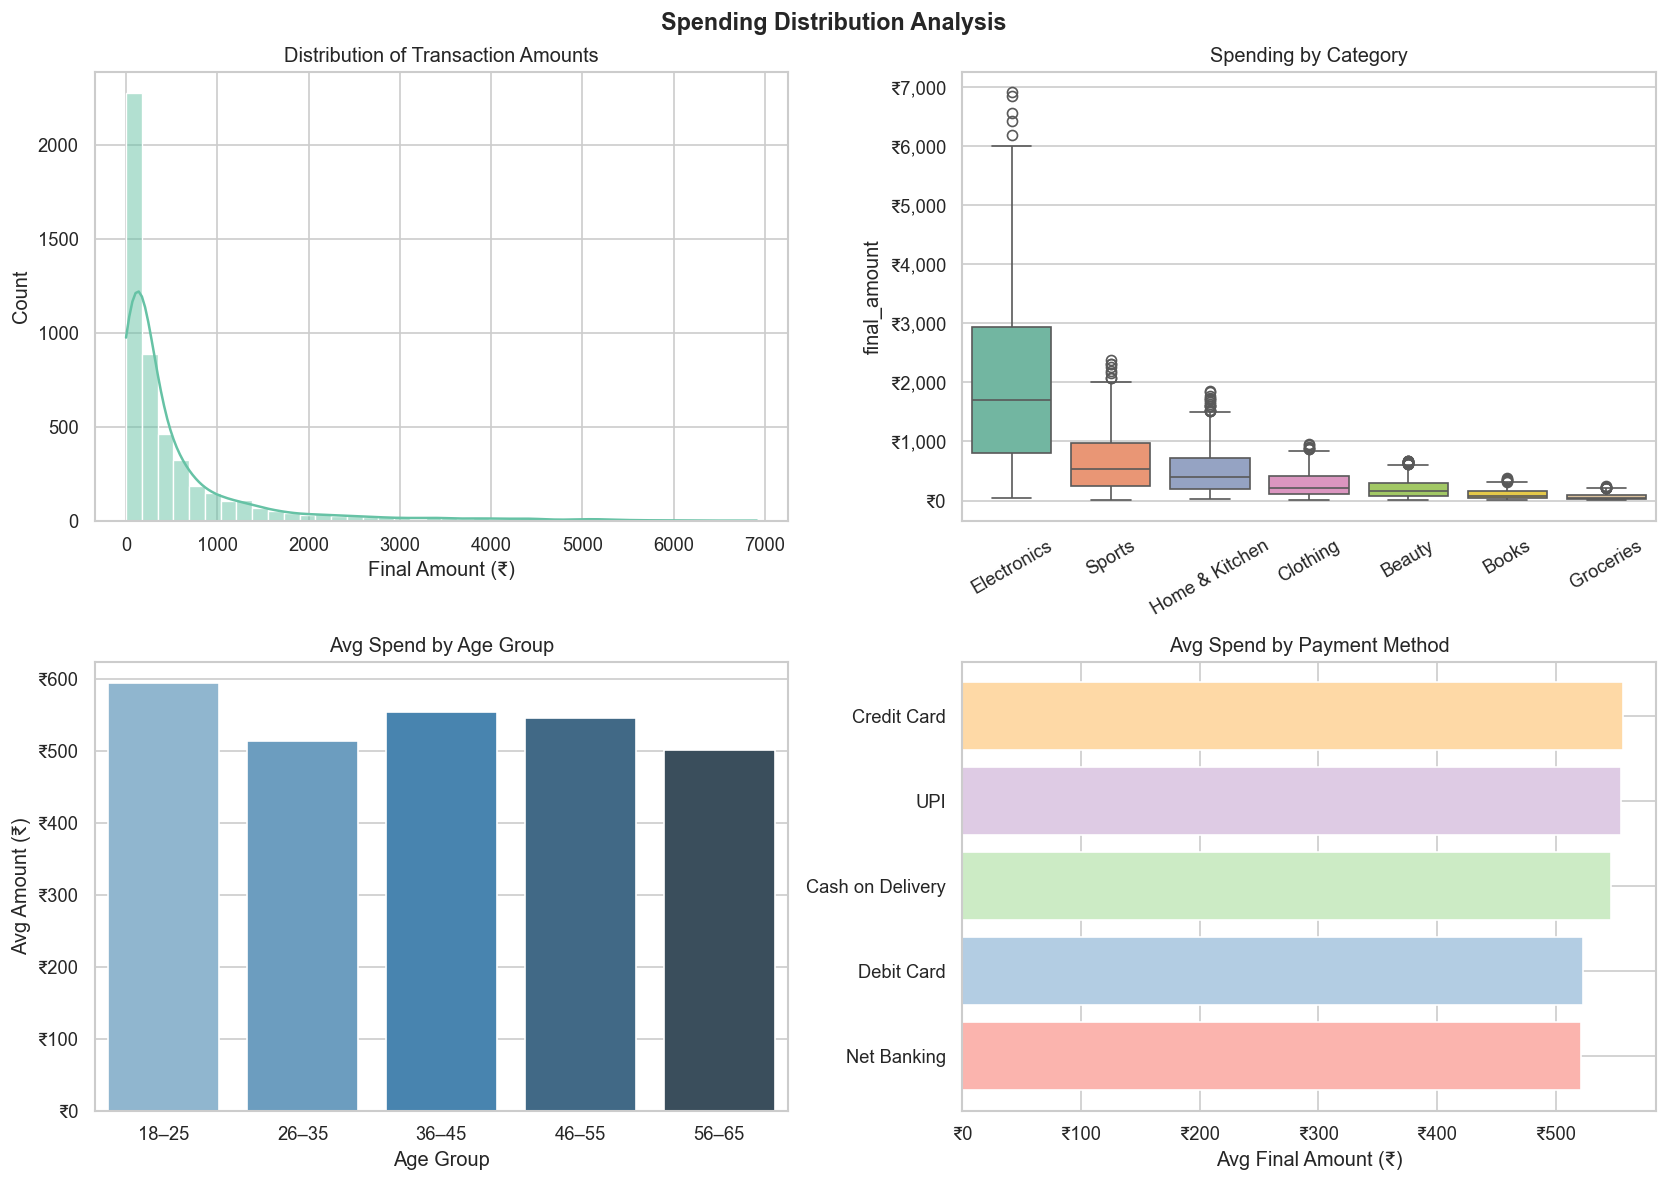

✅ Plot saved: plot4_spending_distribution.png
   📌 Highest avg age group : 18–25 (₹595)
   📌 Highest avg payment   : Credit Card (₹556)


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Spending Distribution Analysis', fontsize=14, fontweight='bold')

# Histogram
sns.histplot(df['final_amount'], bins=40, kde=True, color=PALETTE[0], ax=axes[0,0])
axes[0,0].set_title('Distribution of Transaction Amounts')
axes[0,0].set_xlabel('Final Amount (₹)')

# Box plots per category
order = df.groupby('category')['final_amount'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='category', y='final_amount', order=order, palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Spending by Category')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))

# Avg spend by age group
age_spend = df.groupby('age_group', observed=True)['final_amount'].mean()
sns.barplot(x=age_spend.index.astype(str), y=age_spend.values, palette='Blues_d', ax=axes[1,0])
axes[1,0].set_title('Avg Spend by Age Group')
axes[1,0].set_xlabel('Age Group')
axes[1,0].set_ylabel('Avg Amount (₹)')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))

# Spend by payment method
pay_spend = df.groupby('payment_method')['final_amount'].mean().sort_values()
axes[1,1].barh(pay_spend.index, pay_spend.values, color=sns.color_palette('Pastel1', len(pay_spend)))
axes[1,1].set_title('Avg Spend by Payment Method')
axes[1,1].set_xlabel('Avg Final Amount (₹)')
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('plot4_spending_distribution.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: plot4_spending_distribution.png')
print(f'   📌 Highest avg age group : {age_spend.idxmax()} (₹{age_spend.max():,.0f})')
print(f'   📌 Highest avg payment   : {pay_spend.idxmax()} (₹{pay_spend.max():,.0f})')

---
## 🗺️ Step 10 — City × Day-of-Week Heatmap
Identify which cities and days generate the highest revenue.

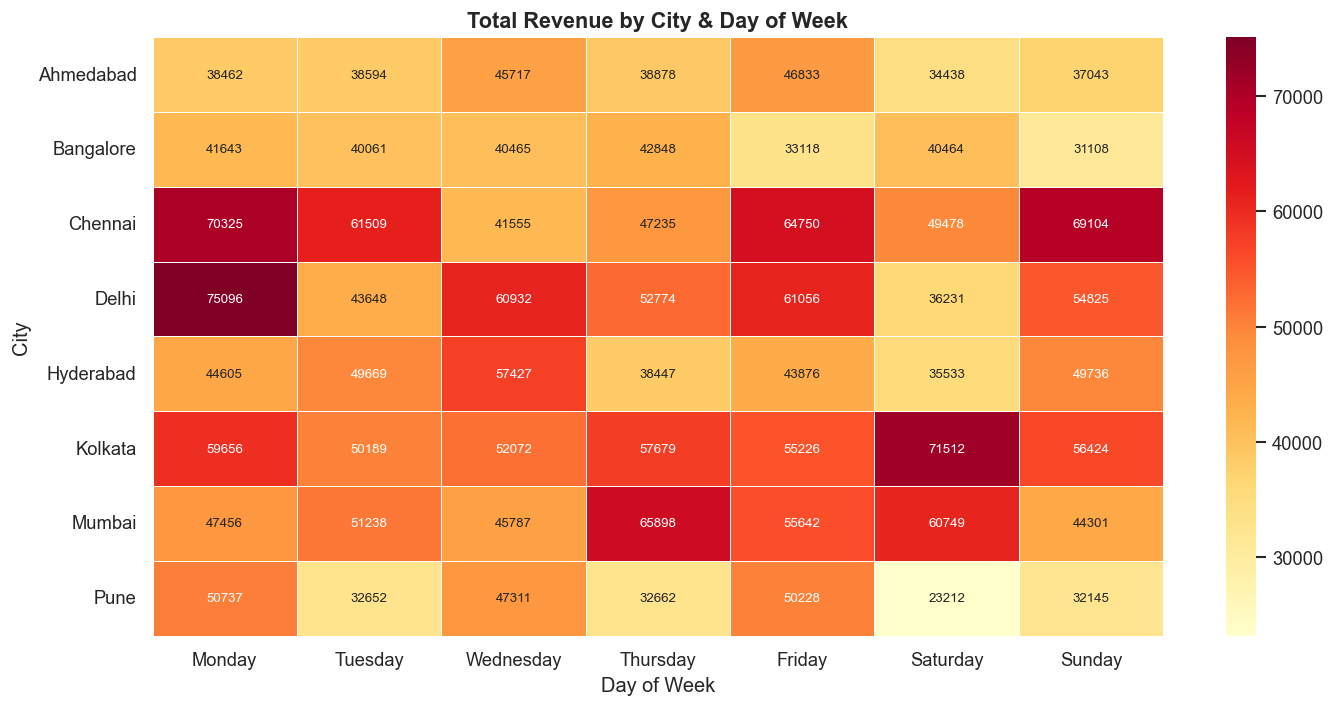

✅ Plot saved: plot5_heatmap.png


In [12]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat_data = df.groupby(['city','day_of_week'])['final_amount'].sum().unstack()
heat_data = heat_data[day_order]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Total Revenue by City & Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('City')
plt.tight_layout()
plt.savefig('plot5_heatmap.png', bbox_inches='tight')
plt.show()
print('✅ Plot saved: plot5_heatmap.png')

---
## 📁 Step 11 — Export Customer Summary Report

In [13]:
summary_df = rfm.merge(
    df.groupby('customer_id').agg(
        preferred_category = ('category',       lambda x: x.value_counts().idxmax()),
        preferred_payment  = ('payment_method', lambda x: x.value_counts().idxmax()),
        city               = ('city',  'first'),
        age                = ('age',   'first'),
        gender             = ('gender','first'),
    ).reset_index(), on='customer_id')

summary_df.to_csv('customer_summary.csv', index=False)
print(f'✅ Exported customer_summary.csv  ({len(summary_df)} rows)')
print()
print('Preview:')
summary_df[['customer_id','Segment','Recency','Frequency','Monetary','preferred_category','city']].head(8)

✅ Exported customer_summary.csv  (500 rows)

Preview:


,customer_id,Segment,Recency,Frequency,Monetary,preferred_category,city
0,CUST0001,Loyal Customers,35,11,4064.00,Groceries,Delhi
1,CUST0002,Champions,87,15,12009.37,Books,Mumbai
2,CUST0003,Lost,143,8,2543.99,Groceries,Hyderabad
3,CUST0004,Champions,26,12,10504.10,Electronics,Chennai
4,CUST0005,Champions,8,11,6490.59,Books,Chennai
5,CUST0006,Potential Loyalists,31,11,2426.58,Books,Bangalore
6,CUST0007,Potential Loyalists,55,8,5722.27,Electronics,Delhi
7,CUST0008,Loyal Customers,28,11,4636.28,Beauty,Delhi


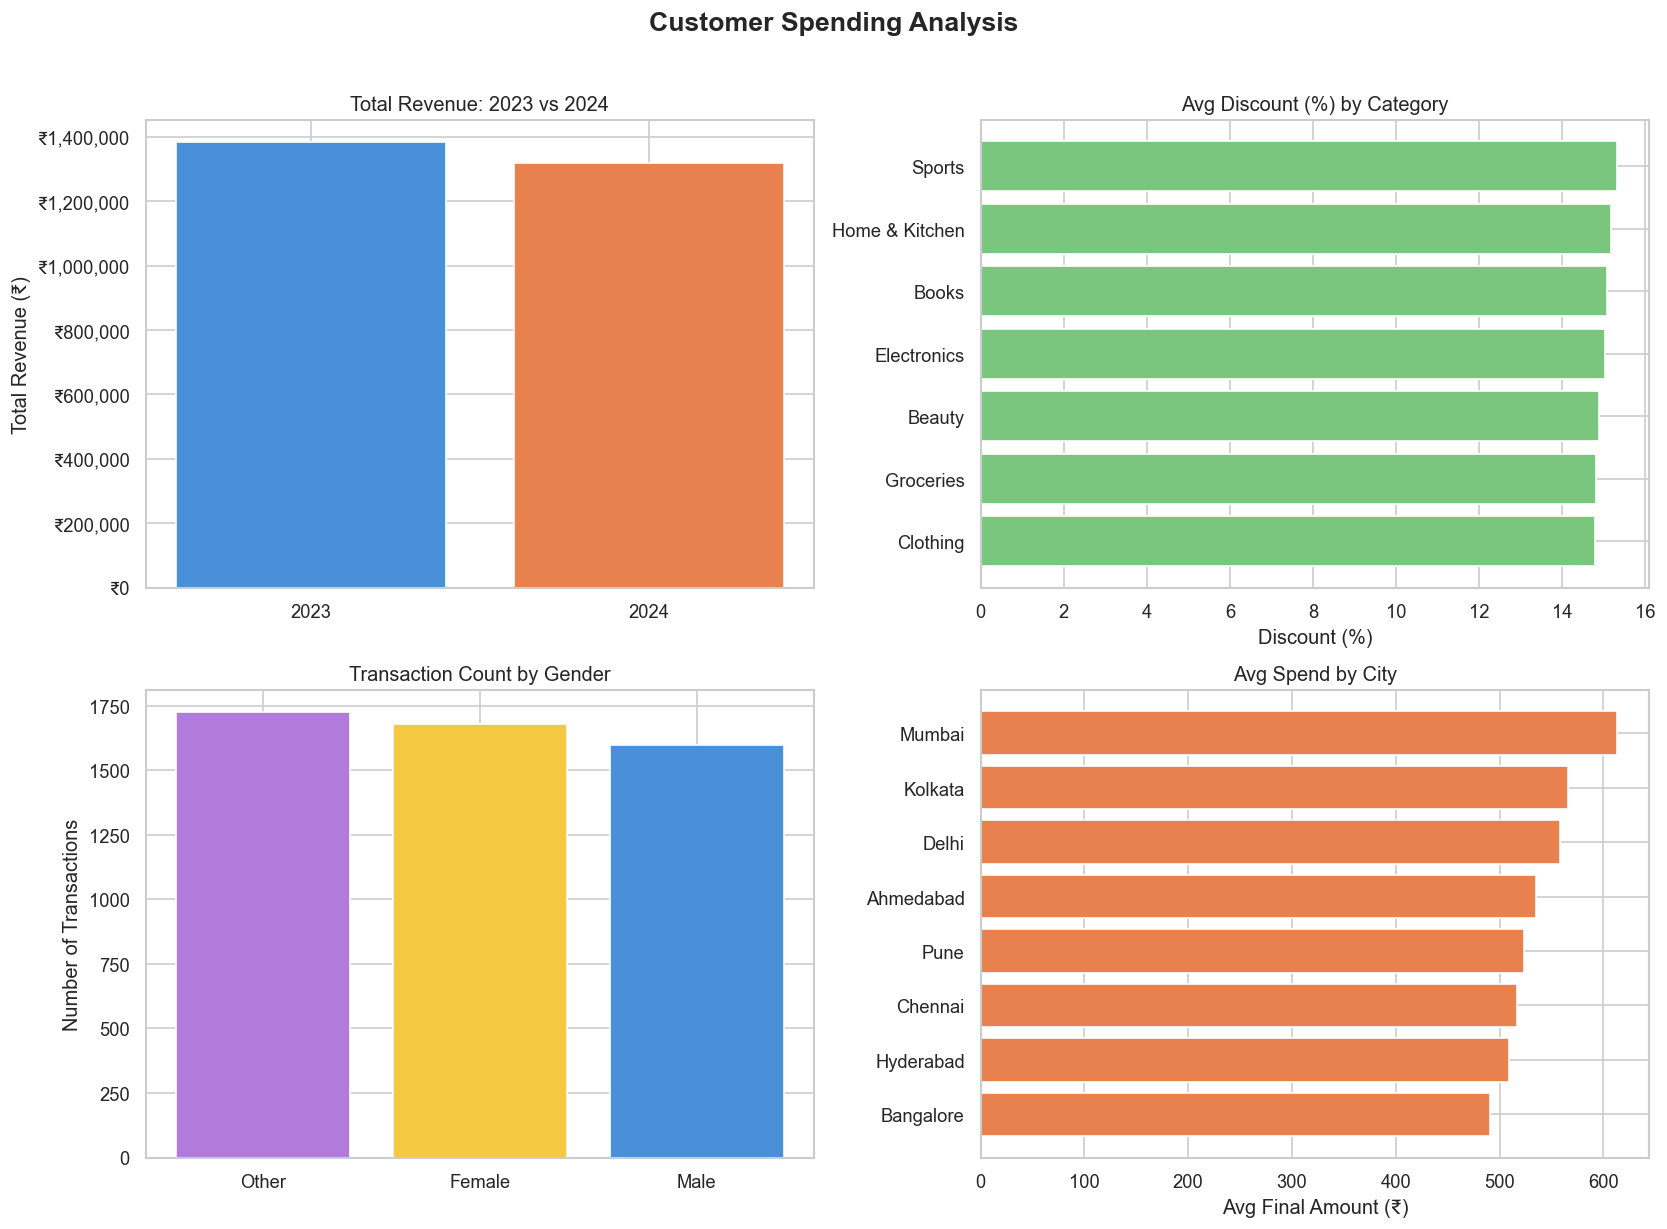

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Spending Analysis', fontsize=16, fontweight='bold', y=1.02)

# Panel 1: Revenue by Year (2023 vs 2024) - replaces histogram
yearly = df.groupby('year')['final_amount'].sum()
axes[0, 0].bar(yearly.index.astype(str), yearly.values, color=['#4A90D9', '#E8814D'], edgecolor='white')
axes[0, 0].set_title('Total Revenue: 2023 vs 2024')
axes[0, 0].set_ylabel('Total Revenue (₹)')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

# Panel 2: Avg Discount by Category - replaces box plot
disc = df.groupby('category')['discount'].mean().sort_values() * 100
axes[0, 1].barh(disc.index, disc.values, color='#7BC67E')
axes[0, 1].set_title('Avg Discount (%) by Category')
axes[0, 1].set_xlabel('Discount (%)')

# Panel 3: Transaction Count by Gender - replaces age group bar
gender = df['gender'].value_counts()
axes[1, 0].bar(gender.index, gender.values, color=['#B07BDA', '#F5C842', '#4A90D9'])
axes[1, 0].set_title('Transaction Count by Gender')
axes[1, 0].set_ylabel('Number of Transactions')

# Panel 4: Avg Spend by City - replaces payment method bar
city = df.groupby('city')['final_amount'].mean().sort_values()
axes[1, 1].barh(city.index, city.values, color='#E8814D')
axes[1, 1].set_title('Avg Spend by City')
axes[1, 1].set_xlabel('Avg Final Amount (₹)')

plt.tight_layout()
plt.savefig('spending_analysis_panel2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ All Steps Complete!

| Output File | Description |
|-------------|-------------|
| `customer_transactions.csv` | Raw dataset — 5,000 transactions |
| `customer_summary.csv` | RFM segment per customer |
| `plot1_sales_trends.png` | Monthly revenue & order count |
| `plot2_top_products.png` | Top products & category share |
| `plot3_rfm_segmentation.png` | RFM customer segments |
| `plot4_spending_distribution.png` | Spending patterns |
| `plot5_heatmap.png` | City × Day revenue heatmap |
| `plot_correlation.png` | Correlation matrix |

---
### 🔑 Key Findings
- **Revenue** stays consistently between ₹80K–₹1.4L/month with a **peak in July 2024**
- **Electronics** is the top revenue category at **22% share**
- **127 Champion customers** drive the highest monetary value (avg ₹8,586)
- **Age group 36–45** has the highest average spend per transaction
- **UPI** is the most popular payment method in India